# Diffusive Approximation of Advective contribution to atmospheric energy budget
Below I compare the direct empirical fit of the advective term to a diffusive parameterization.

In [166]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D
import scipy.optimize
from scipy.interpolate import CubicSpline, UnivariateSpline
from scipy.ndimage import gaussian_filter1d

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic, combine_amplitude_phase_factor
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff as get_heat_cap_lambda_eff2
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots
from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [3]:
from time import perf_counter


def timed_step(label, func):
    """Run func(), print elapsed time, and return its result."""
    start = perf_counter()
    result = func()
    elapsed = perf_counter() - start
    print(f"{label:<55} {elapsed:8.2f} s")
    return result


get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt,
                                             input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                              ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])

In [7]:
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
odp_vals = [0.6, 0.8, 1, 1.5, 2, 2.5, 3, 3.5]
odp_vals_xr = xr.DataArray(odp_vals, dims="odp", name='odp')
n_exp = len(odp_vals)

test = True     # only a few experiments
lat_target = 40
ds_base = []
if test:
    n_exp_sl = 2
    odp_slice = np.arange(n_exp_sl)
else:
    n_exp_sl = n_exp
    odp_slice = np.arange(n_exp)
for i, val in tqdm(enumerate(np.asarray(odp_vals, dtype=object)[odp_slice]), total=n_exp_sl):
    ds_use = utils.load_ds(f"k={str(val).replace('.','_')}", exp_dir, lat_target=lat_target,
                           first_month_file=2 if 'column' in exp_dir else 25, verbose=test, n_lat=1)
    ds_base.append(ds_use)
ds_base = xr.concat(ds_base, dim=odp_vals_xr[odp_slice]).squeeze()
ds = utils.process_ds(ds_base)
feedback_params = utils.get_empirical_params(ds, include_phase_lh='tau_sweep' in exp_dir)    # only have phase if unconstrained simulation

  0%|          | 0/2 [00:00<?, ?it/s]


Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:51<00:00, 17.24s/it]

Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:51<00:00, 17.18s/it]


## Diffusion approximation

The zonal-mean atmospheric energy budget is

$$
\frac{1}{g}
\int_{0}^{p_s}
\frac{\partial \left(c_p T + L_v q\right)}{\partial t}
\, \mathrm{d}p
=
f F(t)
-
\mathrm{OLR}
+
SH^{\uparrow}
+
LH^{\uparrow}
+
LW_s^{\uparrow}
-
LW_s^{\downarrow}
-
\frac{1}{g}
\int_{0}^{p_s}
\frac{\partial \left[v\left(c_p T + L_v q\right)\right]}{\partial y}
\, \mathrm{d}p.
$$

The meridional energy-advection contribution is therefore

$$
-\frac{1}{g}
\int_{0}^{p_s}
\frac{\partial \left[v\left(c_p T + L_v q\right)\right]}{\partial y}
\, \mathrm{d}p.
$$

A common diffusive parameterisation of this term in energy-balance models is

$$
\frac{D e^{-i\phi_D}}{c_p \cos\theta}
\frac{\partial}{\partial \theta}
\left[
\cos\theta
\frac{\partial \left(c_p T_{\mathrm{col}} + L_v q_{\mathrm{col}}\right)}
{\partial \theta}
\right],
$$

where $\theta$ is latitude and $D$ is a diffusivity coefficient, with units of $\mathrm{W\,m^{-2}\,K^{-1}}$ under this formulation. The phase factor $e^{-i\phi_D}$ is non-standard in conventional diffusive energy-balance models, but is included here to represent a phase shift in the seasonal response.

To solve the two-layer differential equations independently at a single location, I approximate the advective term as

$$
-\lambda_{\mathrm{adv}} e^{-i\phi_{\mathrm{adv}}}
\left(T_a - \overline{T}_a\right).
$$

This can be decomposed into dry-static-energy and latent-energy contributions:

$$
-\lambda_{\mathrm{adv}} e^{-i\phi_{\mathrm{adv}}}
\left(T_a - \overline{T}_a\right)
=
-
\left(
\lambda_{\mathrm{dry}} e^{-i\phi_{\mathrm{dry}}}
+
\lambda_{\mathrm{moist}} e^{-i\phi_{\mathrm{moist}}}
\right)
\left(T_a - \overline{T}_a\right).
$$

Comparing this form with the diffusion parameterisation, define dimensionless coefficients $\beta_{\mathrm{dry}}$ and $\beta_{\mathrm{moist}}$, together with their respective phase shifts, by

$$
-\beta_{\mathrm{dry}} e^{-i\phi_{\beta,\mathrm{dry}}}
\left(T_a - \overline{T}_a\right)
=
\frac{1}{c_p \cos\theta}
\frac{\partial}{\partial\theta}
\left[
\cos\theta
\frac{\partial \left(c_p T_{\mathrm{col}}\right)}
{\partial\theta}
\right],
$$

and

$$
-\beta_{\mathrm{moist}} e^{-i\phi_{\beta,\mathrm{moist}}}
\left(T_a - \overline{T}_a\right)
=
\frac{1}{c_p \cos\theta}
\frac{\partial}{\partial\theta}
\left[
\cos\theta
\frac{\partial \left(L_v q_{\mathrm{col}}\right)}
{\partial\theta}
\right].
$$

The advective contribution may then be represented in two equivalent aggregate forms:

$$
\begin{aligned}
-\frac{1}{g}
\int_{0}^{p_s}
\frac{\partial \left[v\left(c_p T + L_v q\right)\right]}
{\partial y}
\, \mathrm{d}p
&=
-
\left(
\lambda_{\mathrm{dry}} e^{-i\phi_{\mathrm{dry}}}
+
\lambda_{\mathrm{moist}} e^{-i\phi_{\mathrm{moist}}}
\right)
\left(T_a - \overline{T}_a\right)
\\
&=
-
D e^{-i\phi_D}
\left(
\beta_{\mathrm{dry}} e^{-i\phi_{\beta,\mathrm{dry}}}
+
\beta_{\mathrm{moist}} e^{-i\phi_{\beta,\mathrm{moist}}}
\right)
\left(T_a - \overline{T}_a\right).
\end{aligned}
$$

Although these two expressions are intended to represent the same total advective contribution, their dry and moist decompositions need not coincide exactly. The $\lambda$-based decomposition is diagnosed from the advective energy transport itself, whereas the $\beta$-based decomposition arises from separately applying the diffusion operator to dry-static and latent column-energy terms.

In [160]:
def remove_mean(var, dim='time'):
    return var - var.mean(dim=dim)

def meridional_diffusion_deriv(var, lat_name: str = "lat"):
    r"""Calculate the spherical meridional diffusion operator.

    Computes

    $$
    \frac{1}{\cos\phi}
    \frac{\partial}{\partial\phi}
    \left(
        \cos\phi
        \frac{\partial \mathrm{var}}{\partial\phi}
    \right),
    $$

    where $\phi$ is latitude in radians. Finite differences are second-order
    accurate at interior grid cells and use second-order one-sided stencils at
    the latitude boundaries.

    Args:
        var (xarray.DataArray): Field containing a one-dimensional latitude
            dimension and coordinate.
        lat_name (str, optional): Name of the latitude dimension and coordinate
            in degrees north. Defaults to ``"lat"``.

    Returns:
        xarray.DataArray: Meridional diffusion operator of ``var`` with respect
        to latitude in radians.

    Raises:
        ValueError: If fewer than three latitudes are available.
    """
    if var.sizes[lat_name] < 3:
        raise ValueError(
            f"At least 3 points are required along {lat_name!r}; "
            f"got {var.sizes[lat_name]}."
        )

    phi_name = f"{lat_name}_rad"
    phi = np.deg2rad(var[lat_name])

    # Add a radians coordinate sharing the latitude dimension.
    var_phi = var.assign_coords({phi_name: phi})
    cos_phi = np.cos(var_phi[phi_name])

    first_deriv = var_phi.differentiate(phi_name, edge_order=2)
    second_deriv = (
        (cos_phi * first_deriv)
        .differentiate(phi_name, edge_order=2)
        / cos_phi
    )

    return second_deriv

get_var_shift_simple = lambda x, y, shift_phase: get_var_shift(x, time=y, shift_phase=shift_phase)
get_var_shift_xr = wrap_with_apply_ufunc(get_var_shift_simple, input_core_dims=[['time'], ['time'], []],
                                         output_core_dims=[['time']])

def decompose_adv_diffuse(temp_col: xr.DataArray, sphum_col: xr.DataArray, mse_adv: xr.DataArray,
                          time: xr.DataArray, temp_atm: xr.DataArray):
    r"""Decompose meridional MSE transport into dry and moist diffusive components.

    Fits a complex, seasonally phase-shifted diffusion coefficient relating the
    meridional diffusion operator applied to column moist static energy (MSE) to
    the diagnosed MSE advection. It then fits dimensionless dry and moist
    scaling coefficients that relate each component of the diffusion operator
    to the low-level atmospheric temperature anomaly.

    The fitted representation is

    $$
    \mathcal{A}_{\mathrm{MSE}}
    \approx
    -D e^{-i\phi_D}
    \left(
        \beta_{\mathrm{dry}} e^{-i\phi_{\beta,\mathrm{dry}}}
        +
        \beta_{\mathrm{moist}} e^{-i\phi_{\beta,\mathrm{moist}}}
    \right)
    T_a',
    $$

    where $T_a'$ denotes the seasonal anomaly of `temp_atm`. The dry and moist
    contributions are reconstructed separately and returned along with their
    sum.

    Args:
        temp_col (xarray.DataArray): Column temperature quantity used to form
            dry-static energy, typically a pressure-weighted or vertically
            integrated temperature field.
        sphum_col (xarray.DataArray): Column specific-humidity quantity used
            to form latent energy, on the same grid and with compatible time
            coordinates as `temp_col`.
        mse_adv (xarray.DataArray): Diagnosed meridional advection of column
            moist static energy to be represented by the diffusion
            parameterisation.
        time (str): Name of the time dimension used when fitting the seasonal
            harmonic amplitude and phase.
        temp_atm (xarray.DataArray): Low-level atmospheric temperature used as
            the local predictor for the reconstructed transport components.
            The fitting convention uses `-temp_atm`.

    Returns:
        tuple: A tuple containing:

            - D (xarray.DataArray): Diffusion coefficient, rescaled by
              `c_p` after fitting.
            - D_phase (xarray.DataArray): Phase shift of the fitted diffusion
              coefficient, in the units returned by
              `utils.get_fit_coef_complex_xr`.
            - beta_dry (xarray.DataArray): Dimensionless dry-component
              scaling coefficient.
            - beta_dry_phase (xarray.DataArray): Phase shift associated with
              `beta_dry`.
            - beta_moist (xarray.DataArray): Dimensionless moist-component
              scaling coefficient.
            - beta_moist_phase (xarray.DataArray): Phase shift associated with
              `beta_moist`.
            - adv_reconstructed (xarray.DataArray): Mean-removed reconstructed
              total transport, equal to the sum of dry and moist components.
            - dry_cont (xarray.DataArray): Mean-removed reconstructed
              dry-static-energy contribution.
            - moist_cont (xarray.DataArray): Mean-removed reconstructed
              latent-energy contribution.

    Notes:
        The dry and moist terms are fitted independently after applying the
        diffusion operator. Consequently, their decomposition is not
        necessarily identical to a dry--moist decomposition diagnosed directly
        from the advective MSE transport.
    """
    # Diffusion operator applied to total column moist static energy.
    var = meridional_diffusion_deriv(c_p * temp_col + L_v * sphum_col)

    # Fit mse_adv ≈ (D / c_p) exp(-i D_phase) var, then rescale D by c_p.
    D, D_phase = utils.get_fit_coef_complex_xr(
        mse_adv, var, time, pos_amp=True
    )
    D = D * c_p

    # Fit dimensionless dry and moist response factors against -temp_atm.
    beta_dry, beta_dry_phase = utils.get_fit_coef_complex_xr(
        meridional_diffusion_deriv(c_p * temp_col) / c_p,
        -temp_atm,
        time,
        pos_amp=True,
    )
    beta_moist, beta_moist_phase = utils.get_fit_coef_complex_xr(
        meridional_diffusion_deriv(L_v * sphum_col) / c_p,
        -temp_atm,
        time,
        pos_amp=True,
    )

    # Reconstruct each transport component, combining its phase with D_phase.
    dry_cont = utils.apply_fit_complex_xr(
        -temp_atm,
        D * beta_dry,
        beta_dry_phase + D_phase,
    )
    moist_cont = utils.apply_fit_complex_xr(
        -temp_atm,
        D * beta_moist,
        beta_moist_phase + D_phase,
    )

    return (
        D,
        D_phase,
        beta_dry,
        beta_dry_phase,
        beta_moist,
        beta_moist_phase,
        remove_mean(dry_cont + moist_cont),
        remove_mean(dry_cont),
        remove_mean(moist_cont),
    )


In [161]:
adv_diffuse = {}
feedback_params['D'], feedback_params['D_phase'], feedback_params['beta_dry'], feedback_params['beta_phase_dry'], feedback_params['beta_moist'], \
    feedback_params['beta_phase_moist'], adv_diffuse['total'], adv_diffuse['dry'], adv_diffuse['moist'] = \
    decompose_adv_diffuse(ds.temp_col, ds.sphum_col, ds.adv_atmos, ds.time, ds.temp_atm)

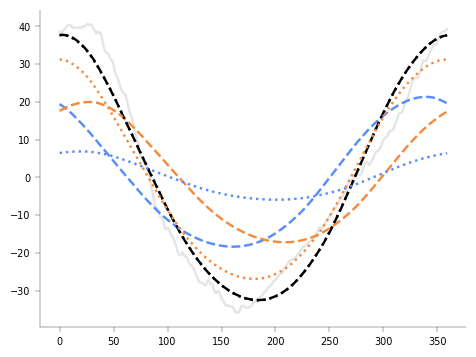

In [159]:
lat_ind = 1
odp_ind = 1
ds_use = ds.isel(lat=lat_ind, odp=odp_ind)
for key in ['', '_dry', '_moist']:
    ds_use[f'adv_atmos_empirical{key}'] = utils.apply_fit_complex_xr(-remove_mean(ds_use.temp_atm),
                                                                     feedback_params[f'lambda_adv{key}'].isel(lat=lat_ind, odp=odp_ind),
                                                           feedback_params[f'coef_phase_adv{key}'].isel(lat=lat_ind, odp=odp_ind))
fig, ax = plt.subplots(1, 1)
fig_resize(fig, utils.width['two_col'])
ax.plot(ds.time, remove_mean(ds_use[f"adv_atmos"]), color='k', alpha=0.1)
for i, key in enumerate(['', '_dry', '_moist']):
    # ax.plot(ds.time, remove_mean(ds_use[f"adv_atmos{key}"]), color=['k', 'C0', 'C1'][i], alpha=0.2)
    ax.plot(ds.time, remove_mean(ds_use[f"adv_atmos_empirical{key}"]), color=['k', 'C0', 'C1'][i], linestyle='--')
ax.plot(ds.time, adv_diffuse['total'].isel(lat=lat_ind, odp=odp_ind), color='k', linestyle=':')
ax.plot(ds.time, adv_diffuse['moist'].isel(lat=lat_ind, odp=odp_ind), color='C0', linestyle=':')
ax.plot(ds.time, adv_diffuse['dry'].isel(lat=lat_ind, odp=odp_ind), color='C1', linestyle=':')
update_linewidth(fig)
plt.show()
# decompose_adv_diffuse(ds.temp_col, ds.sphum_col, ds.adv_atmos, ds.time, D_phase=True)[3].isel(lat=2, odp=1).plot()
# decompose_adv_diffuse(ds.temp_col, ds.sphum_col, ds.adv_atmos, ds.time, D_phase=False)[3].isel(lat=2, odp=1).plot()
# var = ds.adv_atmos - ds.adv_atmos.mean(dim='time')
# var.isel(lat=2, odp=1).plot(color='k')

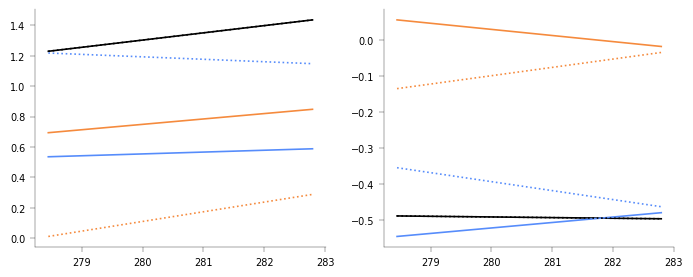

In [192]:
lat_ind = 1
ds_use = ds.isel(lat=lat_ind)
params_use = {key: feedback_params[key].isel(lat=lat_ind) for key in feedback_params}
var_x = ds_use.temp_surf.mean(dim='time')

fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)

# Empirical version
# ax[0].plot(var_x, params_use['lambda_adv']*np.cos(params_use['coef_phase_adv']), color='k')
lambda_use, phase_use = combine_amplitude_phase_factor([params_use['lambda_adv_moist'], params_use['lambda_adv_dry']],
                               [params_use['coef_phase_adv_moist'], params_use['coef_phase_adv_dry']])
ax[0].plot(var_x, lambda_use, color='k')
ax[1].plot(var_x, phase_use, color='k')
for i, key in enumerate(['_dry', '_moist']):
    ax[0].plot(var_x, params_use[f'lambda_adv{key}']*np.cos(params_use[f'coef_phase_adv{key}']), color=f"C{i}")
    ax[1].plot(var_x, params_use[f'lambda_adv{key}']*np.sin(params_use[f'coef_phase_adv{key}'])/lambda_use, color=f"C{i}")

# Diffusion version
lambda_use, phase_use = combine_amplitude_phase_factor([params_use['D']*params_use['beta_dry'], params_use['D']*params_use['beta_moist']],
                               [params_use['D_phase']+params_use['beta_phase_dry'], params_use['D_phase']+params_use['beta_phase_moist']])
ax[0].plot(var_x, lambda_use, color='k', linestyle=':')
ax[1].plot(var_x, phase_use, color='k', linestyle=':')
for i, key in enumerate(['_dry', '_moist']):
    ax[0].plot(var_x, params_use['D']*params_use[f'beta{key}']*np.cos(params_use['D_phase']+params_use[f'beta_phase{key}']),
               color=f"C{i}", linestyle=':')
    ax[1].plot(var_x, params_use['D']*params_use[f'beta{key}']*np.sin(params_use['D_phase']+params_use[f'beta_phase{key}'])/lambda_use,
               color=f"C{i}", linestyle=':')
update_linewidth(fig)

plt.show()

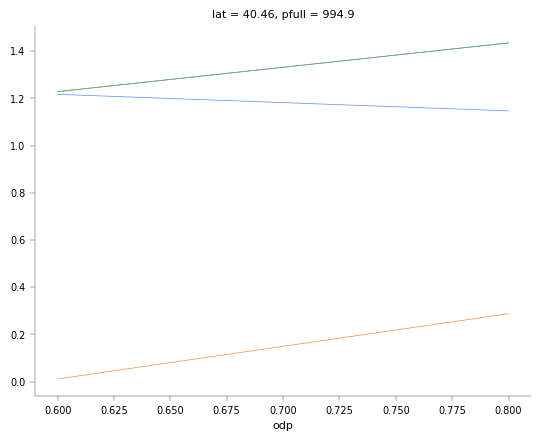

In [182]:
(feedback_params['D']*feedback_params['beta_dry']*np.cos(feedback_params['beta_phase_dry']+feedback_params['D_phase'])).isel(lat=1).plot()
(feedback_params['D']*feedback_params['beta_moist']*np.cos(feedback_params['beta_phase_moist']+feedback_params['D_phase'])).isel(lat=1).plot()
lambda_full = feedback_params['D']*feedback_params['beta_dry']*np.cos(feedback_params['beta_phase_dry']+feedback_params['D_phase']) + \
    feedback_params['D']*feedback_params['beta_moist']*np.cos(feedback_params['beta_phase_moist']+feedback_params['D_phase'])
lambda_full.isel(lat=1).plot()
(feedback_params['lambda_adv']*np.cos(feedback_params['coef_phase_adv'])).isel(lat=1).plot()
# feedback_params['beta_dry'].isel(lat=1).plot()

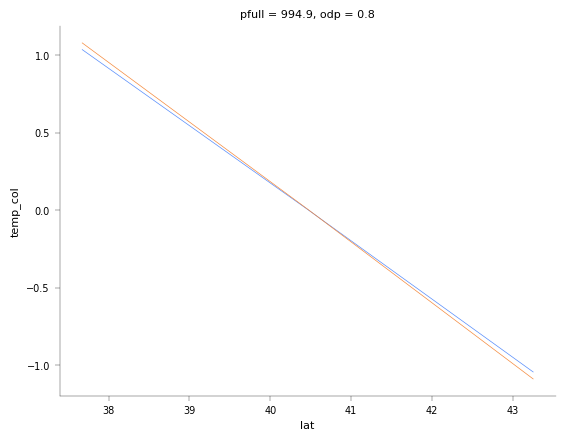

In [147]:
var = ds.temp_col.mean(dim='time')
var = var - var.mean(dim='lat')
var.isel(odp=0).plot()
var.isel(odp=1).plot()